In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tsim

# Team STAR: Step1    

We start from the circuit it was given with d=3 and visualize it in the STAR architecture. We'll go for a 1000 samples and use detector to show outcomes of flips.

In [96]:
N=1000
d=3
c = tsim.Circuit.from_file("star_d=3.stim")
detector_sampler = c.compile_detector_sampler()
samples = detector_sampler.sample(shots=N)
c.diagram("pyzx", height=3000);

Another usefull way to visualize it is by using diagrams separated by time TICKS. It becomes clear to read about every single qubit infomation and study how operations works.

In [104]:
c.diagram("timeslice-svg", height=2000)

Doing form basic calculation just to familiarize with the outcome. A general error can be measure. However this error in his general cannot tell us about internal noises or logical errors so we'll need to explore it.

In [88]:
samples.shape

(1000, 56)

In [90]:
error= samples.astype(int).mean()
error

np.float64(0.01594642857142857)

From diagrams and sample shape we see we have 8 detectors for each of the seven repetition od the circuit so the total detector registration are 56. To start analyzing how error behave within each round and detector we first isolate the first two rounds and analyzing their rate 

In [100]:
samples2 = samples[:, :16]
print (np.mean(samples2))
print (np.std(samples2))

0.029
0.16780643611018023


In [103]:
#Detector Error Rate
r1 = samples[:, :8]
r2 = samples[:, 8:16]

In [104]:
print (np.mean(r1))
print (np.std(r2))

0.015
0.20285709255532575


To explore time evolving error in the qubit we introduce "events" with is a logical XOR over the detector result over the first two round. The goal is detect if and where the error flip from a round to another. 

In [105]:
events= r1^r2
events.shape

(1000, 8)

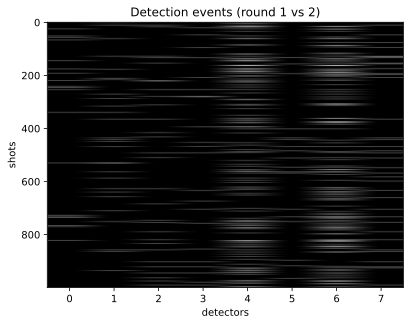

In [106]:
plt.imshow(events, aspect='auto', cmap='gray')
plt.title("Detection events (round 1 vs 2)")
plt.xlabel("detectors")
plt.ylabel("shots")
plt.show()

We do osserve that on detectors 4 and 6 there's a concentration of flips that does not appear on other detectors. From here we wonder what's happening and if something like this occurs in other rounds. With this starting point we extend our view on all the rounds. We declare a list outcomes that trace for evey round all measurement by detectors so we can comment differencese in different round and study time development.

In [67]:
D=samples.shape[1]
R=int(D/8)
outcomes = []
for i in range(R):
    outcomes.append(samples[:, i*8:(i+1)*8])

In [68]:
print(len(outcomes))  
print(outcomes[0].shape)

7
(500, 8)


Calculating again the rates so we got average error for every round

In [69]:
rates = []

for i in range(R):
    data = outcomes[i].astype(int)
    rates.append(float(data.mean()))

print(rates)

[0.0095, 0.04425, 0.011, 0.01325, 0.0125, 0.011, 0.00625]


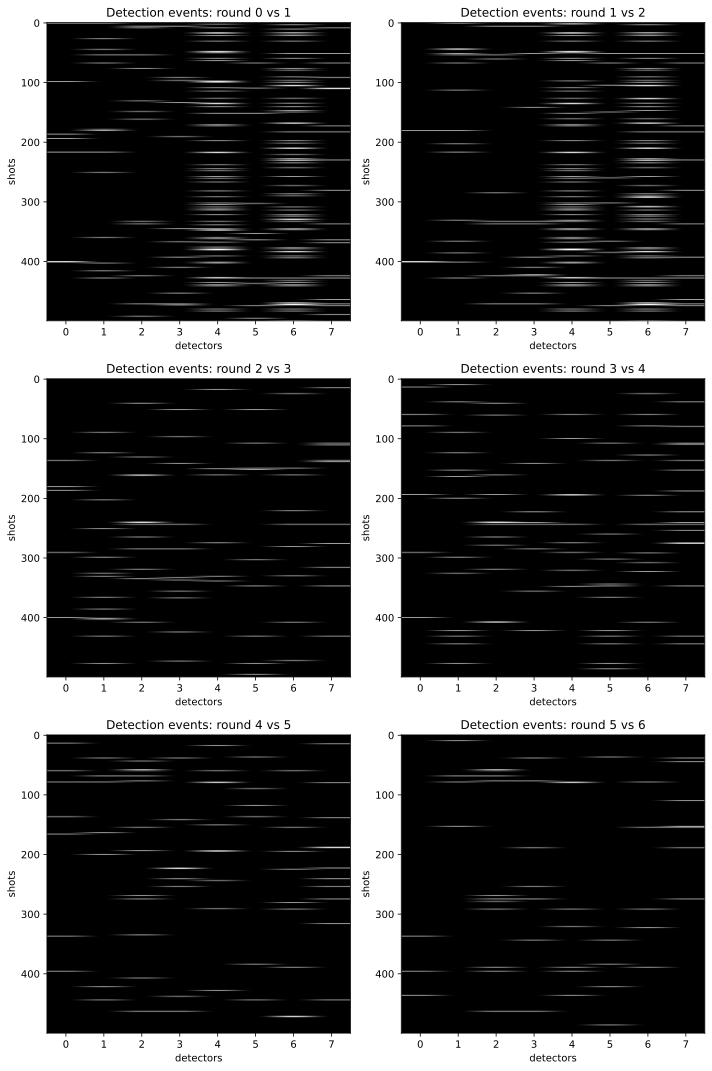

In [114]:
events = []
rows, cols = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(10, 15))
axes = axes.flatten()

for r in range(R - 1):
    events.append(outcomes[r] ^ outcomes[r + 1])
    
    axes[r].imshow(events[r], aspect='auto', cmap='gray')
    axes[r].set_title(f"Detection events: round {r} vs {r+1}")
    axes[r].set_xlabel("detectors")
    axes[r].set_ylabel("shots")

plt.tight_layout()
plt.show()

We note that the density of error over 4 and 6 detectors vanish with round step. Anyway we do investigate this noise a bit more

In [73]:
events = np.array(events)
detector_rates = events.mean(axis=(0,1))

print(detector_rates)

[0.01033333 0.02166667 0.02233333 0.01866667 0.05066667 0.01733333
 0.054      0.02533333]


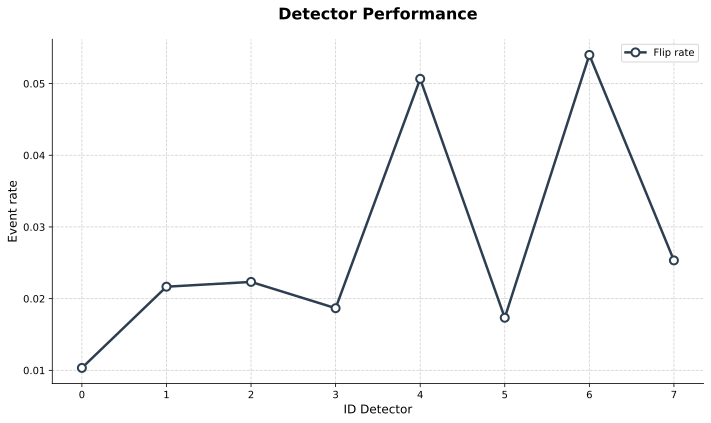

In [115]:
plt.figure(figsize=(10, 6), dpi=100) 

plt.plot(detector_rates, 'o-', 
         linewidth=2.5, 
         markersize=8, 
         markerfacecolor='white', 
         markeredgewidth=2, 
         color='#2c3e50', 
         label='Flip rate')

plt.grid(True, linestyle='--', alpha=0.6)

plt.title("Detector Performance", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("ID Detector", fontsize=12)
plt.ylabel("Event rate", fontsize=12)

for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.gca().spines['bottom'].set_visible(True)
plt.gca().spines['left'].set_visible(True)

plt.legend()
plt.tight_layout() 
plt.show()

In [74]:
corr_46 = np.mean(events[:,:,4] & events[:,:,6])

print(corr_46)

0.019


In [75]:
p4 = detector_rates[4]
p6 = detector_rates[6]

print(p4 * p6)

0.0027359999999999997


In [117]:
indice_carino = corr_46 / (p4 * p6)
print(f"Coincidence ratio: {indice_carino:.2f}")

Coincidence ratio: 6.94


We obtained that there a great incidence of flips in 4 and 6 detectors (6% of flips between two rounds). Also we measure correlation and we gain a ratio really greater the one. The two flips are related so they do occurs in the same situation. It is plausible then they have the same explanaition. Checking the circuits those are positionated in the position we applied the tre rotations. It emerge there's a link between rotation perform and error flipping. Anyway as we saw before this flips vanish as circuits go one. we can conferm that with an heat map of the flips: 

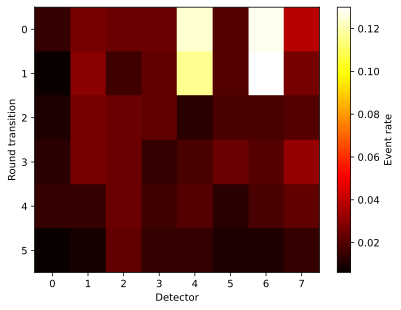

In [77]:
heat = events.mean(axis=1)

plt.imshow(heat, cmap='hot', aspect='auto')

plt.xlabel("Detector")
plt.ylabel("Round transition")

plt.colorbar(label="Event rate")

plt.show()

Heat map confirms that interaction between round1-round2 and round2-round3 do present an high rate of flips. This rate decrease with interaction between round3 and 4 so the system come back to be homogenously stable in term of error distribution. 
This prove solidity of the STAR architecture: flips do not spread over time and they get mitigate from architecture structure